# The Bohr model, 13.6 eV, and Moseley's law
### from the hydrogen spectrum to the atomic number that orders the periodic table

The Bohr model quantizes the atom: $E_n=-\dfrac{13.6\,Z^2}{n^2}$ eV. The **13.6 eV** is
the Rydberg energy -- the work to ionize hydrogen -- and the differences between
levels are the spectral lines (Lyman, Balmer, ...). **Moseley's law** is the same
formula turned into a ruler for the elements: a characteristic K-alpha X-ray is a
$2\to1$ inner-shell transition with the nucleus screened to $(Z-1)$, so
$\sqrt{f}\propto(Z-1)$ -- a straight line that revealed **atomic number = nuclear
charge** and reordered the periodic table. It ties straight to the X-ray tube
(`griffiths/modern.py`): the characteristic lines sit on the bremsstrahlung
continuum. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from griffiths import atomic as at
from griffiths import modern as mp
eV = 1.602176634e-19
print(f"Rydberg energy = {at.rydberg_energy():.4f} eV")

Rydberg energy = 13.6057 eV


## 1. The Bohr energy levels and the hydrogen spectrum

The levels crowd toward 0 as $-13.6/n^2$. Transitions down to $n=1$ are the Lyman
(UV) series, to $n=2$ the Balmer (visible) series. The famous red H-alpha line is
$3\to2$ at 656 nm.

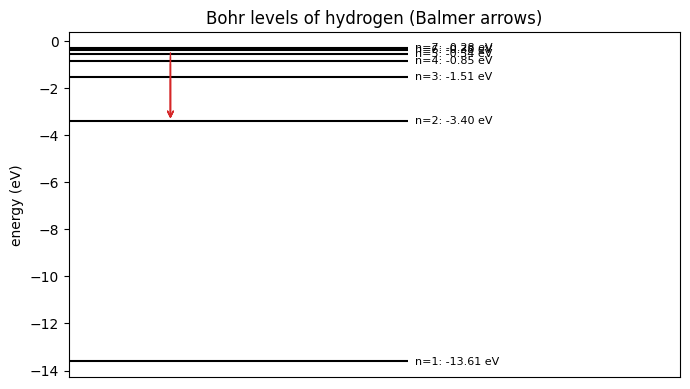

  Balmer H-alpha (3->2): 656.1 nm
  Balmer H-beta (4->2): 486.0 nm
  Lyman-alpha (2->1): 121.5 nm (UV)


In [2]:
n = np.arange(1, 8)
E = at.bohr_energy_level(n)
plt.figure(figsize=(7,4))
for ni, Ei in zip(n, E):
    plt.hlines(Ei, 0, 1, color="k")
    plt.text(1.02, Ei, f"n={ni}: {Ei:.2f} eV", va="center", fontsize=8)
# Balmer transitions (down to n=2)
for nh in (3,4,5,6):
    plt.annotate("", xy=(0.3, at.bohr_energy_level(2)), xytext=(0.3, at.bohr_energy_level(nh)),
                 arrowprops=dict(arrowstyle="->", color="C3"))
plt.xlim(0,1.8); plt.ylabel("energy (eV)"); plt.title("Bohr levels of hydrogen (Balmer arrows)")
plt.xticks([]); plt.tight_layout(); plt.show()
for nh, name in [(3,"H-alpha"),(4,"H-beta")]:
    print(f"  Balmer {name} ({nh}->2): {at.hydrogen_line_wavelength(2,nh)*1e9:.1f} nm")
print(f"  Lyman-alpha (2->1): {at.hydrogen_line_wavelength(1,2)*1e9:.1f} nm (UV)")

## 2. Moseley's law -- the straight line that found atomic number

Plot $\sqrt{f}$ of the K-alpha X-ray against $Z$ for the elements. It is a **straight
line through $Z=1$** -- Moseley (1913) measured exactly this and concluded the line
frequency is set by the **nuclear charge** $Z$, not atomic weight. Gaps in the line
predicted undiscovered elements.

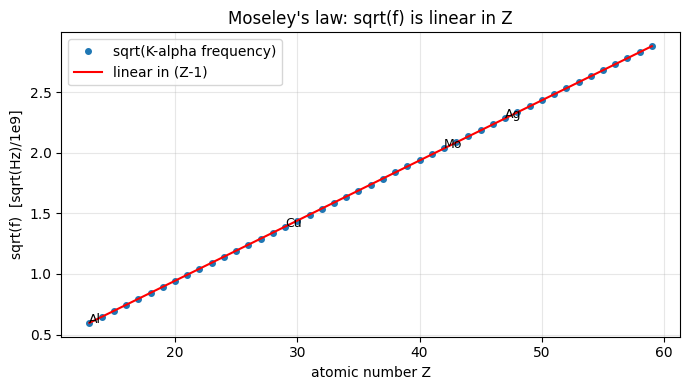

Cu K-alpha = 8.00 keV,  Mo K-alpha = 17.15 keV


In [3]:
Z = np.arange(13, 60)
sqrt_f = np.sqrt([at.moseley_kalpha_frequency(z) for z in Z])
plt.figure(figsize=(7,4))
plt.plot(Z, sqrt_f/1e9, "o", ms=4, label="sqrt(K-alpha frequency)")
slope, b = np.polyfit(Z-1, sqrt_f, 1)
plt.plot(Z, (slope*(Z-1)+b)/1e9, "r-", label="linear in (Z-1)")
for el, z in [("Al",13),("Cu",29),("Mo",42),("Ag",47)]:
    plt.annotate(el, (z, np.sqrt(at.moseley_kalpha_frequency(z))/1e9), fontsize=9)
plt.xlabel("atomic number Z"); plt.ylabel("sqrt(f)  [sqrt(Hz)/1e9]")
plt.title("Moseley's law: sqrt(f) is linear in Z"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Cu K-alpha = {at.moseley_kalpha_energy(29)/1e3:.2f} keV,  "
      f"Mo K-alpha = {at.moseley_kalpha_energy(42)/1e3:.2f} keV")

## 3. Molybdenum: characteristic line on the bremsstrahlung continuum

A molybdenum X-ray tube emits both: the broad **bremsstrahlung** continuum (braking
electrons, with the Duane-Hunt cutoff) AND a sharp **Mo K-alpha** spike at 17.15 keV
(Moseley). Together they are the real X-ray spectrum -- continuum plus characteristic
peaks. (This 17 keV line is the photon used in the Compton notebook.)

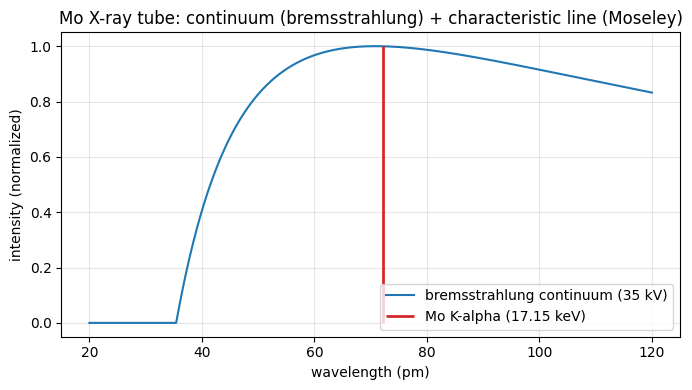

Mo K-alpha wavelength = 72.3 pm, sitting on the continuum


In [4]:
kV = 35.0
lam = np.linspace(20e-12, 120e-12, 3000)
I = mp.bremsstrahlung_spectrum(lam, kV*1e3); I = I/I.max()
lam_Ka = at._H*at._C/(at.moseley_kalpha_energy(42)*eV)        # Mo K-alpha wavelength
plt.figure(figsize=(7,4))
plt.plot(lam*1e12, I, label=f"bremsstrahlung continuum ({kV:.0f} kV)")
plt.vlines(lam_Ka*1e12, 0, 1.0, color="C3", lw=2, label="Mo K-alpha (17.15 keV)")
plt.xlabel("wavelength (pm)"); plt.ylabel("intensity (normalized)")
plt.title("Mo X-ray tube: continuum (bremsstrahlung) + characteristic line (Moseley)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"Mo K-alpha wavelength = {lam_Ka*1e12:.1f} pm, sitting on the continuum")

## What ties together

1. **Bohr / 13.6 eV:** $E_n=-13.6Z^2/n^2$ eV gives the hydrogen spectrum -- Balmer
   (656 nm) in the visible, Lyman in the UV.
2. **Moseley's law:** the same formula for an inner-shell $2\to1$ jump with screening
   $(Z-1)$ makes $\sqrt{f}\propto(Z-1)$ -- a straight line that proved atomic number
   is nuclear charge and ordered the periodic table.
3. **The X-ray tube** shows both at once: a bremsstrahlung continuum plus
   characteristic Moseley lines -- the full picture from the last notebook completed.

From one quantized-energy idea: starlight spectra, the periodic table's order, and
every X-ray source. Civilian education / atomic physics.